In [10]:
import json
from pathlib import Path

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
def read_jsonl(filepath):
    data = []

    with open(filepath, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip():
                data.append(json.loads(line))

    return data

In [12]:
checkpoint_dir = Path("data") / "ch09"

In [13]:
#epoches, steps = [], []
#train_losses, val_losses = [], []
#learning_rates, created_at = [], []

records = []

json_files = sorted(
    checkpoint_dir.glob("checkpoint_*.json"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=False,
)

for f in json_files:
    #print(f"---> file: {f}")
    data = json.loads(f.read_text())

    #tags = f.name.replace("checkpoint_", "").replace(".json", "").split("-", 1)
    #epoch, step = int(tags[0]), int(tags[1])
    records.append((
        data['epoch'], data['step'], data['train_loss'], data['val_loss'],
        data['learning_rate'], data['created_at']),
    )

In [14]:
#df = pd.DataFrame({
#    "epoch": epoches,
#    "step": steps,
#    "train_loss": train_losses,
#    "val_loss": val_losses,
#    "learning_rate": learning_rates,
#    "created_at": created_at,
#})

columns=["epoch", "step", "train_loss", "val_loss", "learning_rate", "created_at"]
df = pd.DataFrame.from_records(records, columns=columns)

df = df.sort_values(by='step', ascending=True)
df.to_csv(checkpoint_dir / "training.tsv", index=False, sep='\t')

In [15]:
#print(df.nsmallest(1, 'train_loss'))
#pd.concat((df.head(10), df.tail(10)))

df.head(15)

,epoch,step,train_loss,val_loss,learning_rate,created_at
0,1,8000,4.483925,4.491979,0.000038,2025-09-15T14:54:44%:z
1,1,16000,3.664065,3.767551,0.000076,2025-09-15T15:25:50%:z
2,1,24000,3.132821,3.307736,0.000114,2025-09-15T15:56:52%:z
3,1,32000,2.760071,2.984072,0.000152,2025-09-15T16:59:42%:z
4,1,40000,2.548054,2.810270,0.000191,2025-09-15T17:44:57%:z
5,1,48000,2.392028,2.710667,0.000229,2025-09-15T18:16:03%:z
6,1,56000,2.291321,2.651382,0.000267,2025-09-15T18:47:07%:z
7,1,64000,2.167756,2.592231,0.000300,2025-09-15T19:18:20%:z
8,1,72000,2.089280,2.563814,0.000300,2025-09-15T19:49:36%:z
9,1,80000,2.011697,2.533019,0.000299,2025-09-15T20:27:55%:z


In [16]:
df.tail(30)

,epoch,step,train_loss,val_loss,learning_rate,created_at
137,9,1040000,1.159693,2.513569,0.000021,2025-09-20T14:28:09%:z
138,9,1048000,1.158705,2.512377,0.000020,2025-09-20T14:59:28%:z
139,9,1056000,1.161089,2.500581,0.000019,2025-09-20T15:30:45%:z
140,9,1064000,1.157651,2.512994,0.000018,2025-09-20T16:02:05%:z
141,9,1072000,1.157811,2.525790,0.000017,2025-09-20T16:33:20%:z
142,9,1080000,1.156539,2.526794,0.000016,2025-09-20T17:04:35%:z
143,9,1088000,1.153611,2.535048,0.000015,2025-09-20T17:35:48%:z
144,9,1096000,1.155278,2.518156,0.000015,2025-09-20T18:07:01%:z
145,9,1104000,1.156017,2.515374,0.000014,2025-09-20T18:38:14%:z
146,9,1112000,1.153090,2.527602,0.000013,2025-09-20T19:09:27%:z


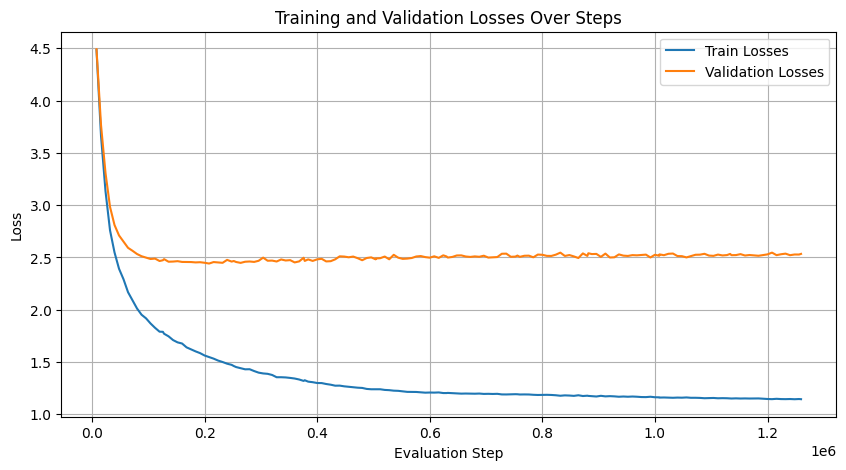

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['train_loss'], label="Train Losses")
plt.plot(df['step'], df['val_loss'], label="Validation Losses")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title("Training and Validation Losses Over Steps")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(checkpoint_dir / "training.pdf")

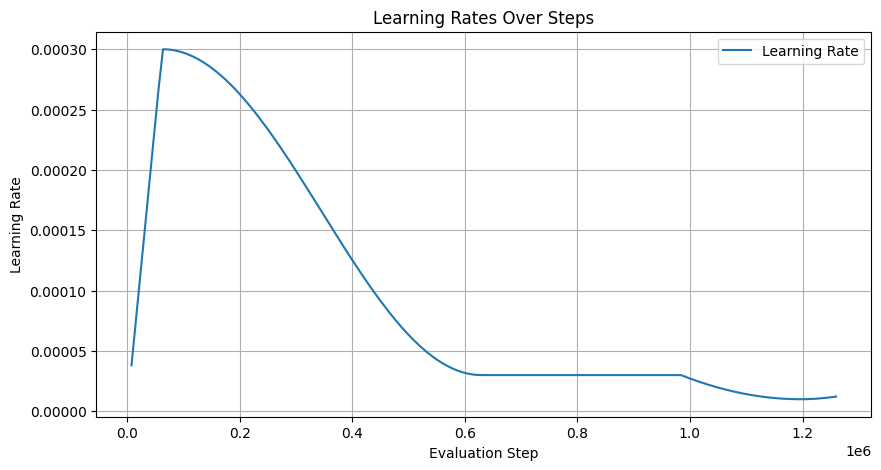

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(df['step'], df['learning_rate'], label="Learning Rate")
plt.xlabel("Evaluation Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rates Over Steps")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(checkpoint_dir / "learning_rate.pdf")